IMPORT LIBRARIES

In [669]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split 
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot

PART 1. Principal Component Analysis

1. Load Data

In [670]:
DigitData =load_digits()
print(f'(#samples, #dimension of each sample) = {DigitData.data.shape}')

(#samples, #dimension of each sample) = (1797, 64)


2. Visualize some data before using PCA

<Figure size 640x480 with 0 Axes>

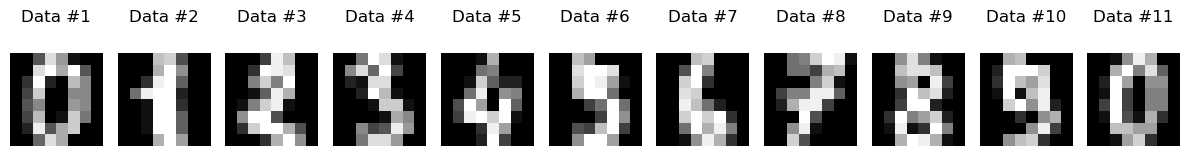

In [671]:
# Set the colormap to gray
plt.gray()  

# Create a figure with 1 row and 11 columns
fig, axes = plt.subplots(1, 11, figsize=(12, 4))  # Adjust figsize as needed

# Plot first 11 data
for i in range(11):
    axes[i].matshow(DigitData.data[i].reshape(8, 8))
    axes[i].set_title(f"Data #{i + 1}")  
    axes[i].axis("off")  

# Adjust layout to make sure titles and plots fit well
plt.tight_layout()
plt.show()

3. Using PCA to reduce the dimension

In [672]:
df = pd.DataFrame(DigitData.data, columns=DigitData.feature_names)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [673]:
# Collect 2 dimensions that contain most % of useful data
pca = PCA(n_components=2)       
less_dimension_data = pca.fit_transform(df)

# Show eigen values (or how many % each new dimension captures useful information)
print(f'Eigen vector = {pca.explained_variance_ratio_}')     

# Show the total percentage useful information that new data capture
print(f'The total percentage of useful information = {sum(pca.explained_variance_ratio_)}')

Eigen vector = [0.14890594 0.13618771]
The total percentage of useful information = 0.2850936482369123


Question 1: What do you observe? 

Answer: 
Before using PCA, several features of original data capture less meaningful information. 
For example, the values of pixel_0_0, pixel_0_1, pixel_6_7, pixel_7_0, pixel_7_1 contain nothing but 0.
Therefore, we want to not include those data

Question 2: What is the percentage of variance captured by these two components? 

Answer:
If we reduce the dimension to 2 components, the total percentage of useful information is just 28.5%.
In fact, we want to capture more data.

 Question 3: Is it sufficient or we should find more components?

Answer: No, we want to capture much more data, let's say we want to capture 95% of useful data.
In the following we are going to show how we achieve that number.

In [674]:
# Select new dimension such that we capture 95% of useful data
pca = PCA(0.95)       
less_dimension_data = pca.fit_transform(df)

# Show eigen values (or how many % each new dimension captures useful information)
print(f'Eigen vector = {pca.explained_variance_ratio_}')     

# Show the total percentage useful information that new data capture
print(f'The total percentage of useful information = {sum(pca.explained_variance_ratio_)}')

Eigen vector = [0.14890594 0.13618771 0.11794594 0.08409979 0.05782415 0.0491691
 0.04315987 0.03661373 0.03353248 0.03078806 0.02372341 0.02272697
 0.01821863 0.01773855 0.01467101 0.01409716 0.01318589 0.01248138
 0.01017718 0.00905617 0.00889538 0.00797123 0.00767493 0.00722904
 0.00695889 0.00596081 0.00575615 0.00515158 0.0048954 ]
The total percentage of useful information = 0.9547965245651597


PART 2. K-mean Clustering

1. Load data

In [675]:
digits = load_digits()
print(f'(#samples, #dimension of each sample) = {digits.data.shape}')

(#samples, #dimension of each sample) = (1797, 64)


2. Preprocess the digits dataset

In [676]:
data = scale(digits.data)
labels = digits.target
images = digits.images

3. Visualize some digits with labels

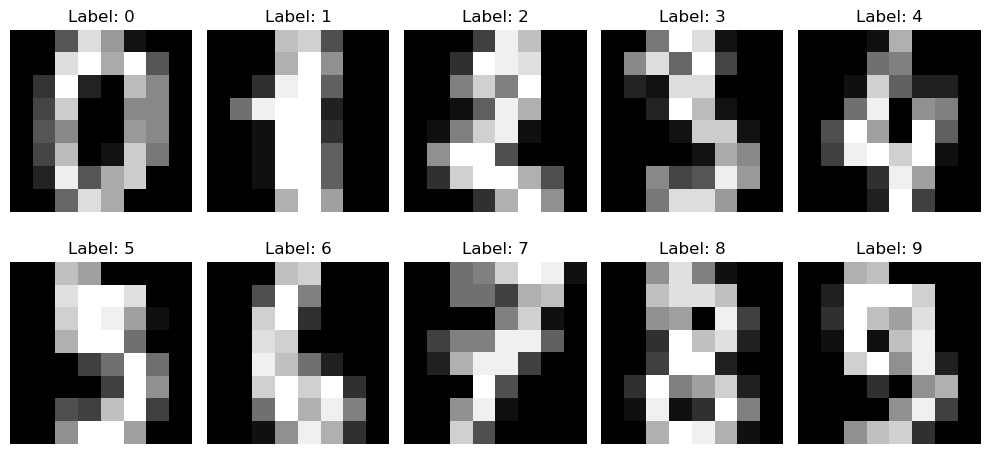

In [677]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, image, label in zip(axes.ravel(), images[:10], labels[:10]):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

4. Apply PCA to reduce the dimensions to 2

In [678]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

5. Visualize the Data on its principal components

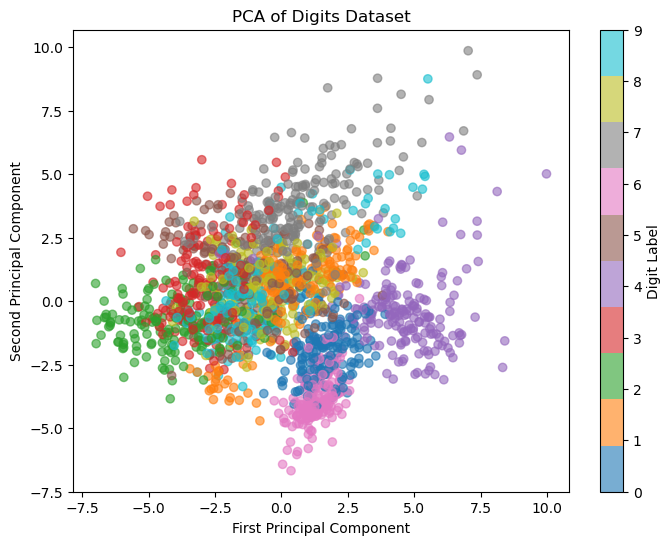

In [679]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA of Digits Dataset")
plt.show()

6. Split data into training and test sets

In [680]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

7. Perform K-mean cluster

In [681]:
# Perform KMeans clustering
kmean = KMeans(init='k-means++',n_clusters=10,random_state=0)
kmean.fit(X_train)
y_pred = kmean.predict(X_test)
print(f'The corresponding predicted clusters that each objects in X_test belongs to is show as below: \n {y_pred}')

The corresponding predicted clusters that each objects in X_test belongs to is show as below: 
 [4 1 1 7 3 5 3 1 3 3 3 8 2 0 2 3 1 6 1 3 2 1 1 6 3 4 1 3 4 1 2 1 5 2 2 4 1
 2 6 4 4 1 3 1 4 8 1 0 4 1 6 3 1 3 4 0 1 0 0 8 0 2 8 3 2 1 6 0 6 1 1 1 1 6
 6 0 2 3 1 1 1 0 3 1 1 0 4 2 2 1 8 5 8 1 1 5 1 0 2 2 2 1 1 1 8 6 3 8 2 5 6
 6 2 2 8 1 6 6 1 6 3 4 1 2 0 6 3 6 3 8 3 1 6 8 0 4 4 2 5 3 0 1 2 4 1 8 4 1
 0 1 1 4 4 0 4 2 5 1 1 3 6 3 1 0 2 3 3 4 6 6 1 3 2 3 3 1 6 6 3 3 1 1 1 0 1
 3 5 3 4 1 1 2 3 3 7 3 1 4 2 3 1 1 1 6 3 1 2 1 3 3 2 2 1 4 3 1 4 0 2 3 3 6
 8 4 2 3 4 0 1 3 1 4 6 8 1 5 2 6 4 3 3 1 3 8 0 5 3 3 6 3 6 4 3 3 5 1 2 1 3
 1 4 0 1 3 6 0 3 0 2 1 3 3 1 4 0 2 5 0 0 1 4 1 1 6 1 6 1 1 1 3 3 1 1 8 0 3
 4 1 2 0 5 2 4 2 1 2 1 0 1 3 5 1 8 2 3 8 6 0 3 3 3 3 3 8 6 0 4 2 3 8 1 3 3
 2 3 3 7 1 3 4 0 4 3 0 7 1 3 1 3 5 6 6 8 1 6 2 1 6 1 1]


c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


8. Show confusion matrix

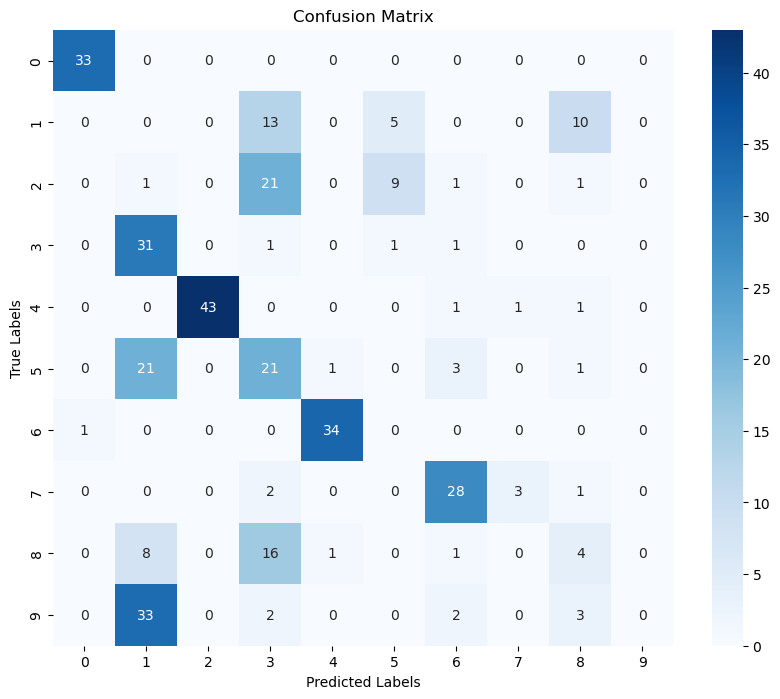

In [682]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()